In [8]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
insurance_data = pd.read_csv("insurance.csv")

# interaction features
X = insurance_data.drop(columns=["charges"]) #input
y = insurance_data["charges"] # output

X = pd.get_dummies(X, columns=["region"], drop_first=True, dtype=int) 

X["sex"] = X["sex"].map({"female":0, "male": 1})
X["smoker"] = X["smoker"].map({"no":0, "yes": 1})

X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]

In [3]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [4]:
lasso_model = Lasso(alpha=0.5)
lasso_model.fit(X_train, y_train)

y_pred = lasso_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("MSE: ", mse)

MSE:  21926877.621013746


In [5]:
lasso_model = Lasso(alpha=0.5) # here we donot know the regularization_strength(alpha) therfore we do hit and try
lasso_model.fit(X_train, y_train)

y_pred = lasso_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("MSE: ", mse)

MSE:  21926877.621013746


MSE for 0.001:  21929190.06383207
MSE for 0.1:  21928719.867663145
MSE for 1:  21924704.682426553
MSE for 2:  21920790.582004
MSE for 3:  21917453.053572323
MSE for 4:  21914691.740735136
MSE for 5:  21912507.09916219
MSE for 10:  21910223.34763369
MSE for 20:  21948840.153853193
MSE for 30:  22045020.87736191
MSE for 100:  23771120.59987643


<Axes: >

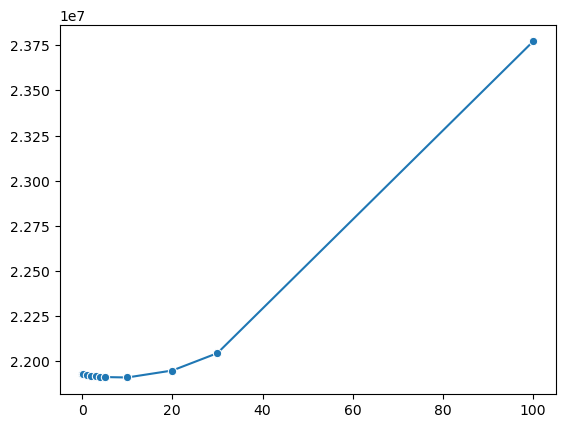

In [6]:
# hit and try for alpha value(lemen technique)
import seaborn as sns
alphas = [0.001, 0.1, 1, 2, 3, 4, 5, 10, 20, 30, 100]
mses=[]

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train, y_train)

    y_pred = lasso_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for {a}: ", mse)
    mses.append(mse)

sns.lineplot(x=alphas, y=mses, marker="o")

In [9]:
#using lassocv gives the best alpha value among the the a array
from sklearn.linear_model import LassoCV
a = [0.001, 0.1, 1, 2, 3, 4, 5, 10, 20, 30, 100]

lassocv_model = LassoCV(
    alphas=a,
    cv=5, # cross validation is the technique where the our data is split into pieces(like 5 in this case) and then
    # each one is called folder and then we do iteration(in this case is max_iter) and in each iter the train and test
    # data is different means(for 1-80train 20test, 2-90train, 10test like this) and the avg is calculated of all of this
    max_iter=1000,
    random_state=42
)
# might get the ConvergenceWarning in that case increase the max_iter value why error occurance because when the 
# cost fnx is finding minimum point it needs more iter for finding the minimum point

lassocv_model.fit(X_train, y_train)

print("best alpha: ", lassocv_model.alpha_)

y_pred = lassocv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"MSE for {lassocv_model.alpha_}: ", mse)
r2 = r2_score(y_test, y_pred)
print("r2: ", r2)

best alpha:  0.001
MSE for 0.001:  21929190.06383207
r2:  0.8503583093672008
